# **Customer Churn Analysis and Prediction**


#### The project aims to analyze customer churn in a telecommunications company and develop predictive models to identify at-risk customers. The ultimate goal is to provide actionable insights and recommendations to reduce churn and improve customer retention.




### **Task 1: Data Preparation**

In [17]:
# Importing the Data from Drive

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [26]:
df = pd.read_csv(r"C:\Users\megha\Downloads\Projects\Customer Churn Analysis and Prediction\Telco_Customer_Churn_Dataset.csv")

In [27]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [29]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [30]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [31]:
(df['TotalCharges']==" ").sum()

np.int64(11)

In [32]:
# Handling Missing Values

import numpy as np
df['TotalCharges']=df['TotalCharges'].replace(" ",np.nan).astype(float)
df['TotalCharges']=df['TotalCharges'].fillna(df['TotalCharges'].median())
print(df['TotalCharges'].dtype)
print((df['TotalCharges']==" ").sum())

float64
0


In [33]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [34]:
df = df.drop(columns='customerID',axis = 1)


In [36]:
df['Churn']

0        No
1        No
2       Yes
3        No
4       Yes
       ... 
7038     No
7039     No
7040     No
7041    Yes
7042     No
Name: Churn, Length: 7043, dtype: object

In [37]:
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})

In [38]:
x = df.drop(columns = 'Churn',axis = 1)
y = df['Churn']

In [39]:
df_encoded = pd.get_dummies(x, dtype=int)

In [50]:
# Splitting into Training & Testing Sets
x_train,x_test,y_train,y_test=train_test_split(df_encoded,y,test_size=0.2,random_state=42,stratify=y)


### **Task 2: Exploratory Data Analysis (EDA)**

Overall Churn Rate: 26.54%


C:\Users\megha\AppData\Local\Temp\ipykernel_41300\128186940.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Churn",data=df,palette=["skyblue", "salmon"])


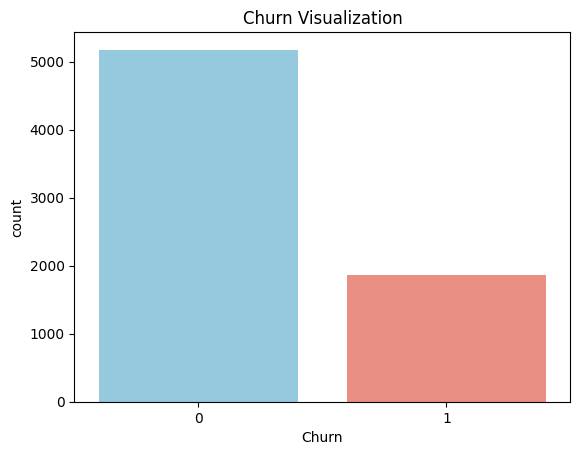

In [41]:
# Overall Churn Rate

import matplotlib.pyplot as plt
import seaborn as sns

churn_rate=df['Churn'].mean()*100
print(f"Overall Churn Rate: {churn_rate:.2f}%")

# Visualizing it

sns.countplot(x="Churn",data=df,palette=["skyblue", "salmon"])
plt.title("Churn Visualization")
plt.show()

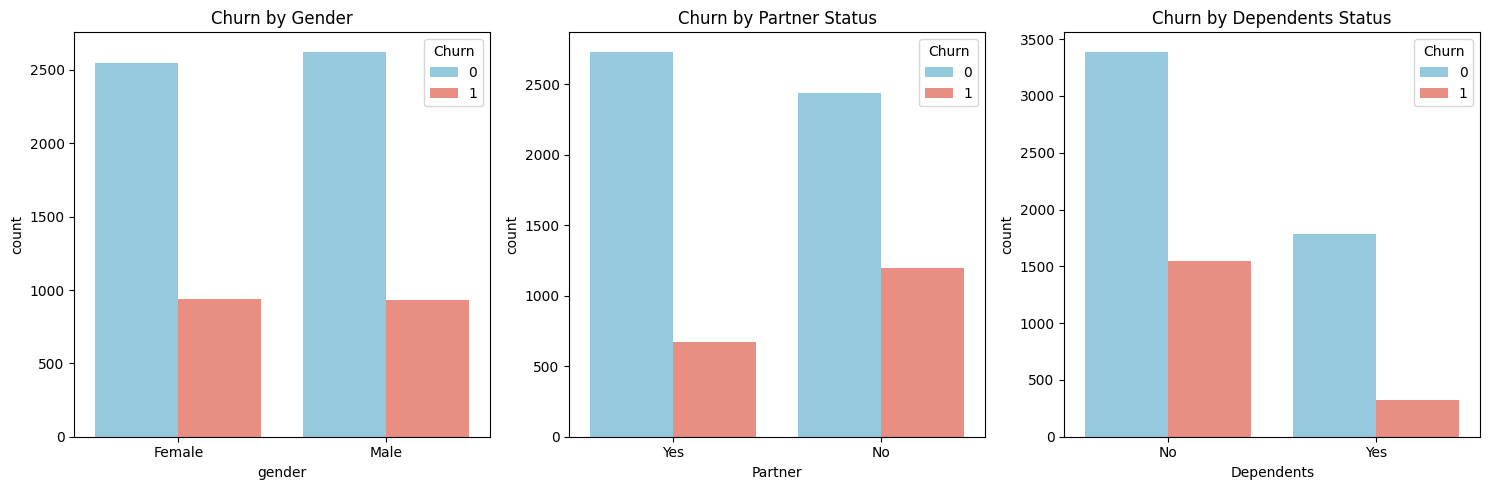

In [10]:
# Customer distribution by gender, partner status, and dependent status

fig,axes=plt.subplots(1,3,figsize=(15,5))

sns.countplot(x='gender',hue='Churn',data=df,ax=axes[0],palette=["skyblue", "salmon"])
axes[0].set_title("Churn by Gender")

sns.countplot(x='Partner',hue='Churn',data=df,ax=axes[1],palette=["skyblue", "salmon"])
axes[1].set_title("Churn by Partner Status")

sns.countplot(x='Dependents',hue='Churn',data=df,ax=axes[2],palette=["skyblue", "salmon"])
axes[2].set_title("Churn by Dependents Status")

plt.tight_layout()
plt.show()

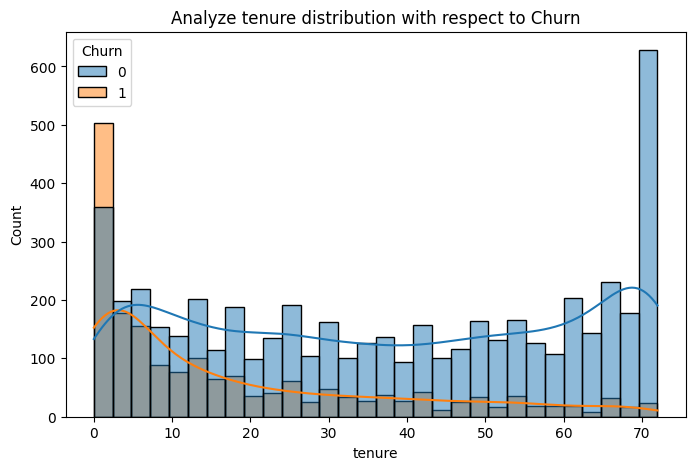

In [42]:
# Analyzing tenure distribution and its relation with churn

plt.figure(figsize=(8,5))
sns.histplot(x='tenure',data=df,hue='Churn',bins=30,kde=True)
plt.title("Analyze tenure distribution with respect to Churn")
plt.show()

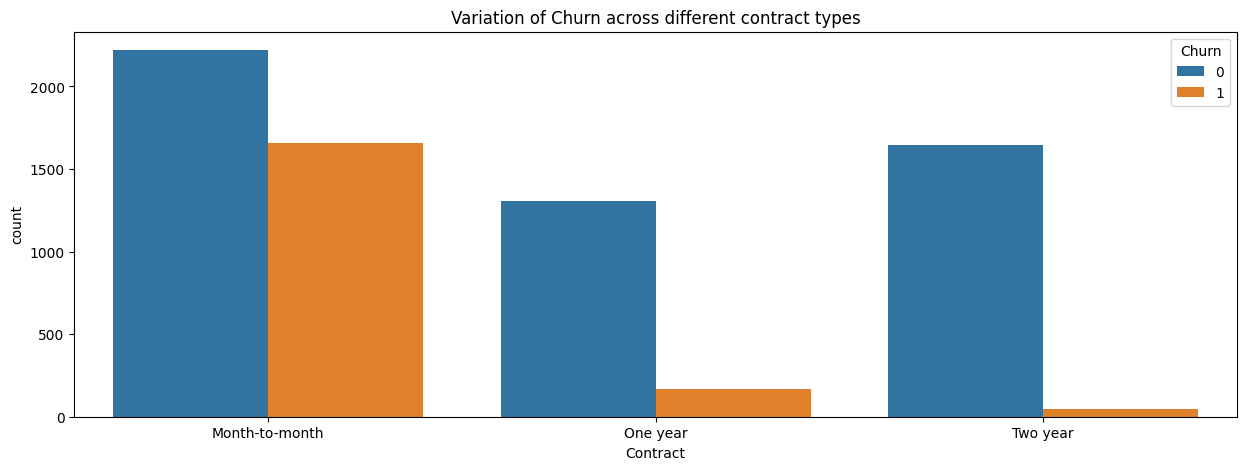

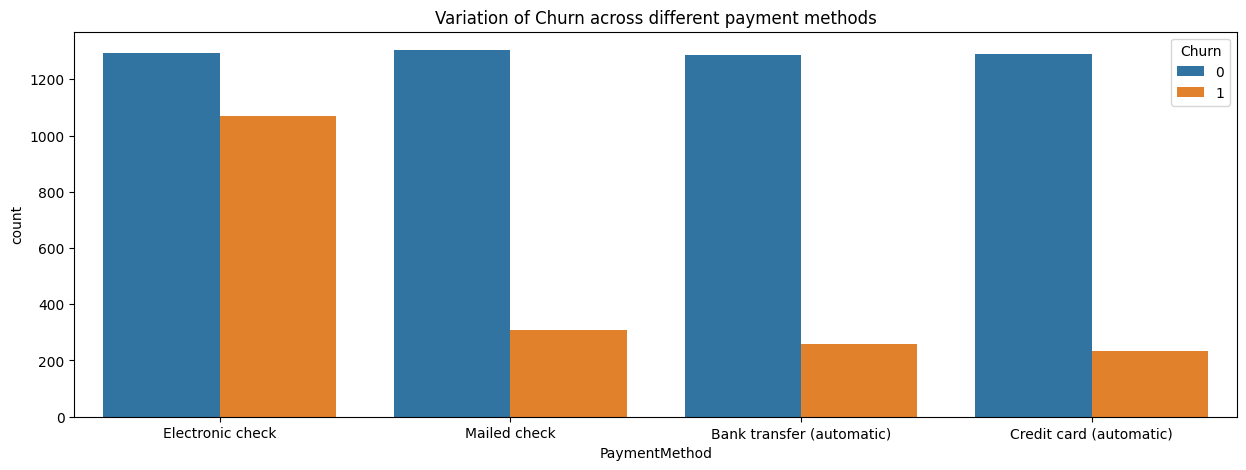

In [12]:
# Variation of Churn across different contract types and payment methods

plt.figure(figsize=(15,5))
sns.countplot(x='Contract',data=df,hue='Churn')
plt.title("Variation of Churn across different contract types")
plt.show()

plt.figure(figsize=(15,5))
sns.countplot(x='PaymentMethod',data=df,hue='Churn')
plt.title("Variation of Churn across different payment methods")
plt.show()

### **Task 3: Customer Segmentation**

In [43]:
# Tenure Segments

print(df['tenure'].max())

df['TenureGroup']=pd.cut(df['tenure'],bins=[0,12,24,48,72],labels=['0-12','13-24','25-48','49-72'],include_lowest=True)


72


In [44]:
# Monthly Charge Segments

print(df['MonthlyCharges'].max())
df['ChargeGroup']=pd.qcut(df['MonthlyCharges'],q=3,labels=['Low','Medium','High'])


118.75


In [15]:
# Analyzing churn rates within Contract type

print("Churn rate by contract type in %")
print((df.groupby('Contract')['Churn'].mean()*100).round(2))

Churn rate by contract type in %
Contract
Month-to-month    42.71
One year          11.27
Two year           2.83
Name: Churn, dtype: float64


In [45]:
# Analyzing churn rates within Tenure

print("Churn rate by Tenure in %")
print((df.groupby('TenureGroup')['Churn'].mean()*100).round(2))

Churn rate by Tenure in %
TenureGroup
0-12     47.44
13-24    28.71
25-48    20.39
49-72     9.51
Name: Churn, dtype: float64


C:\Users\megha\AppData\Local\Temp\ipykernel_41300\1061066698.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print((df.groupby('TenureGroup')['Churn'].mean()*100).round(2))


In [46]:
# Analyzing churn rates within Monthly charges

print("Churn rate by Monthly Charges in %")
print((df.groupby('ChargeGroup')['Churn'].mean()*100).round(2))

Churn rate by Monthly Charges in %
ChargeGroup
Low       15.87
Medium    29.68
High      34.09
Name: Churn, dtype: float64


C:\Users\megha\AppData\Local\Temp\ipykernel_41300\1468798187.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print((df.groupby('ChargeGroup')['Churn'].mean()*100).round(2))


In [18]:
# Analyzing churn rates for combined factors

print("Churn rate for combined factors in %")
print((df.groupby(['Contract','ChargeGroup','TenureGroup'])['Churn'].mean()*100).round(2).sort_values(ascending=False))

Churn rate for combined factors in %
Contract        ChargeGroup  TenureGroup
Month-to-month  High         0-12           74.59
                Medium       0-12           55.95
                High         13-24          53.85
                             25-48          43.54
                Low          0-12           35.88
                Medium       13-24          34.04
                High         49-72          30.97
One year        High         0-12           28.57
Month-to-month  Medium       25-48          27.38
One year        High         13-24          22.22
                             25-48          21.38
                             49-72          19.20
Month-to-month  Low          13-24          18.99
                             49-72          17.65
One year        Medium       0-12           16.67
Month-to-month  Medium       49-72          15.85
                Low          25-48          13.89
One year        Medium       13-24          11.43
                      

/tmp/ipython-input-2336672108.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print((df.groupby(['Contract','ChargeGroup','TenureGroup'])['Churn'].mean()*100).round(2).sort_values(ascending=False))


In [47]:
# Identifying the high valued rsiky customers

risky=df[(df['Contract']=='Month-to-month') & (df['ChargeGroup']== 'High') & (df['TenureGroup']== '0-12')]
print("High valued customers count is: ",risky.shape[0])
print("Churn rate for these customers is: ", (risky['Churn'].mean()*100).round(2))

High valued customers count is:  370
Churn rate for these customers is:  74.59


### **Task 4: Churn Prediction Model**

In [52]:
# Scaling the data before model model training

from sklearn.preprocessing import StandardScaler

scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [53]:
# Training the models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

log_reg=LogisticRegression(max_iter=5000)
log_reg.fit(x_train_scaled,y_train)

dtree=DecisionTreeClassifier(random_state=0)
dtree.fit(x_train_scaled,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [54]:
# Evaluating multiple models using metrics

from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

for model,name in [(log_reg,'Logistic Regression'),(dtree,'Decision Tree')]:
  y_pred=model.predict(x_test_scaled)
  print(f"{name} Performance :")
  print("Accuracy : ",accuracy_score(y_test,y_pred))
  print("Precision : ",precision_score(y_test,y_pred))
  print("Recall : ",recall_score(y_test,y_pred))
  print("F1 Score : ",f1_score(y_test,y_pred))
  print("_"*40)

Logistic Regression Performance :
Accuracy :  0.8062455642299503
Precision :  0.6573208722741433
Recall :  0.5641711229946524
F1 Score :  0.6071942446043166
________________________________________
Decision Tree Performance :
Accuracy :  0.7260468417317246
Precision :  0.48429319371727747
Recall :  0.4946524064171123
F1 Score :  0.4894179894179894
________________________________________


In [55]:
# Feature selection

from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier()
rf.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [56]:
rf.feature_importances_

array([0.01872367, 0.13640931, 0.13954042, 0.16171324, 0.01753623,
       0.01744212, 0.01545256, 0.01450625, 0.01231626, 0.01195663,
       0.00258157, 0.00298573, 0.01340772, 0.00262759, 0.01282421,
       0.01283999, 0.02374331, 0.00203865, 0.02913837, 0.00332987,
       0.01150821, 0.01813559, 0.00223441, 0.01318078, 0.01335502,
       0.00304995, 0.01193878, 0.02412523, 0.00245507, 0.01249879,
       0.01193906, 0.00417775, 0.01128404, 0.01145525, 0.00334858,
       0.01105003, 0.06075145, 0.01199288, 0.01313779, 0.01538065,
       0.01532287, 0.01231907, 0.0131054 , 0.03029514, 0.01084451])

C:\Users\megha\AppData\Local\Temp\ipykernel_41300\1379804568.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=imp_df, palette="viridis")


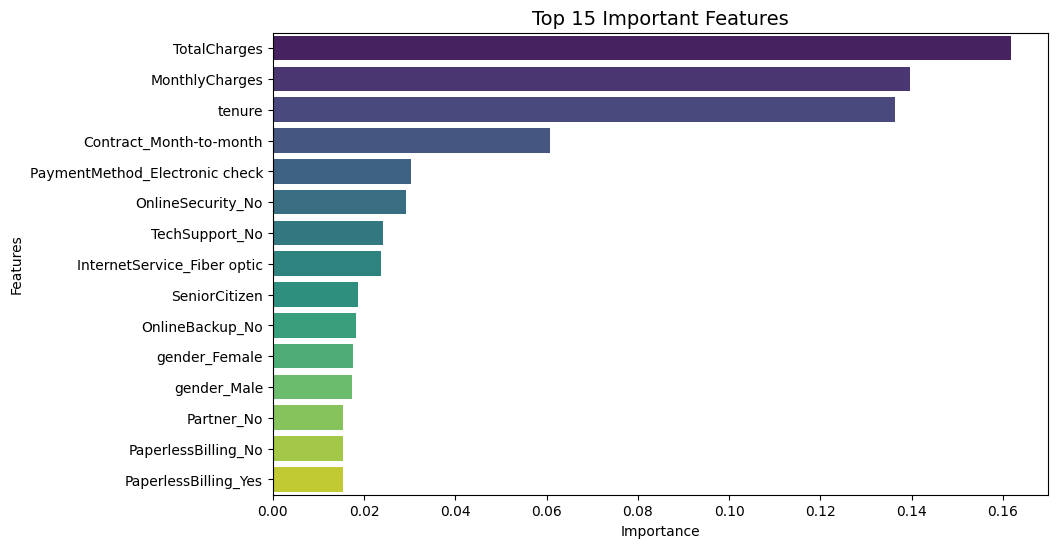

In [59]:
importances = pd.Series(rf.feature_importances_, index=df_encoded.columns).sort_values(ascending=False)
imp_df = importances[:15].reset_index()
imp_df.columns = ["Feature", "Importance"]

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=imp_df, palette="viridis")
plt.title("Top 15 Important Features", fontsize=14)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()

In [60]:
best_features=importances[:15].index
x_train_selected=x_train[best_features]
x_test_selected=x_test[best_features]

In [61]:
# Hyperparameter tuning for Logistic regression

from sklearn.model_selection import GridSearchCV
parameter_grid_log={'C':[0.1,0.5,1,5,20,100],'tol':[0.000001,0.0001,0.01,0.1,1,10,100],'solver':['lbfgs','liblinear','newton-cg','newton-cholesky','sag','saga'],'class_weight':[None,'balanced']}
log_reg_tuned=LogisticRegression()
logistic_grid=GridSearchCV(log_reg_tuned,parameter_grid_log,cv=10)
logistic_grid.fit(x_train_selected,y_train)

c:\Users\megha\anaconda3\envs\megha_455\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\megha\anaconda3\envs\megha_455\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/pre

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 0.5, ...], 'class_weight': [None, 'balanced'], 'solver': ['lbfgs', 'liblinear', ...], 'tol': [1e-06, 0.0001, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter can

In [62]:
print("Best parameters for logistic regression are : ",logistic_grid.best_estimator_)

Best parameters for logistic regression are :  LogisticRegression(C=1, solver='newton-cg', tol=0.01)


In [63]:
# Hyperparameter tuning for Decision Tree

decTree_tuned = DecisionTreeClassifier()
parameter_grid_decTree = {'max_depth':[3,5,10,None],'min_samples_split':[2,5,10],'criterion':['gini','entropy'],'min_samples_leaf':[0.1,0.5,1,2,5,10,100],'class_weight':[None,'balanced']}
decTree_grid = GridSearchCV(decTree_tuned, parameter_grid_decTree, cv=5)
decTree_grid.fit(x_train_selected, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': [None, 'balanced'], 'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [0.1, 0.5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold an

In [64]:
print("Best parameters for Decision Tree are : ",decTree_grid.best_estimator_)

Best parameters for Decision Tree are :  DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=100)


In [65]:
# Evaluating multiple models using metrics after Hyperparameter tuning


for model, name in [(logistic_grid.best_estimator_, "Logistic Regression (Tuned)"),
                    (decTree_grid.best_estimator_, "Decision Tree (Tuned)")]:
    y_pred = model.predict(x_test_selected)
    print(f"{name} Performance:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    print("-"*50)

Logistic Regression (Tuned) Performance:
Accuracy: 0.8019872249822569
Precision: 0.6547231270358306
Recall: 0.5374331550802139
F1 Score: 0.5903083700440529
--------------------------------------------------
Decision Tree (Tuned) Performance:
Accuracy: 0.7955997161107168
Precision: 0.6405228758169934
Recall: 0.5240641711229946
F1 Score: 0.5764705882352941
--------------------------------------------------


##